# Part 3: Water Quality Rating 

Topics covered in this section:

- used tidyverse filter to see how many were above thresholds
- also introduced ifelse in this part 
- summarised by percent of samples that failed test and plotted

*Note: if you are starting from the beginning and have not recently done part 1: Kavi_Tribe_Water_Quality.R, you may want to load your packages and set your working directory*

In [4]:
# load necessary libraries
library(tidyverse)
# make plots larger 
options(repr.plot.width = 12, repr.plot.height = 8)

# important cleaned water quality dataset
water <- read.csv("K-avi_tribe_water_quality_dataset_clean.csv")
tek_sum <- read.csv("tek_summary.csv")

## Rate water quality data 

Use the mutate function to create new columns (one for each water quality metric), that checks if the metric for each measurement date pases or fails based on the K'avi water quality standards, where 1 = pass, 0 = fail

Here we use the `if_else()` function, which takes a conditional and assigns a value based on whether the condition is True or False. For example: 

`if_else(conditional, TRUE, FALSE)` 



In [5]:
water <- water %>%
  mutate(temp_check = if_else(water_temp_C <= 15, 1, 0), # should it be less than OR less than and equal to
         DO_check = if_else(DO >= 12, 1, 0),
         # pH_check = if_else(pH < 7.1, 1, 0)
         # there's no pH dataset in the data you gave me
         SC_check = if_else(specific_conductivity <= 400, 1, 0))

Now that we know when each standard passes / fails, we can count them to figure out how often each sampling location fails based on each measurement.

Next we group by the sample location an summarize the checks. 


In [7]:
rank_sum <- water %>%
  # group the data by the sampling location
  group_by(sample_location) %>%
  # summarize the data
            # get the length (number of samples collected at each site)
  summarise(n_sample = length(temp_check),
            # find the number of times the temperature measurement failed to meet the K'avi standards
            temp_fail = length(which(temp_check == 0)),
            # calculate the % failure rate for temp measurements / site
            temp_percent = temp_fail / n_sample * 100,
            # find the number of times the DO measurement failed to meet the K'avi standards
            DO_fail = length(which(DO_check == 0)),
            # calculate the % failure rate for DO measurements / site
            DO_percent = DO_fail / n_sample * 100,
            # find the number of times the specific conductivity measurement
            # failed to meet the K'avi standards
            SC_fail = length(which(SC_check == 0)),
            # calculate the % failure rate for temp measurements / site
            SC_percent = SC_fail / n_sample * 100,
            # calculate the average failure rate for each site across all water
            # quality measurements
            average_fail = mean(c(temp_percent, DO_percent, SC_percent)))

## create a new data frame that merges water quality ranking data with TEK data
dat <- inner_join(rank_sum, tek_sum)

Joining with `by = join_by(sample_location)`


## Visualize the data 

Next we plot the average failure rate for each monitoring site on x-axis against the average TEK ranking based on site pairings

Warning message:
"The `<scale>` argument of `guides()` cannot be `FALSE`. Use "none" instead as of ggplot2 3.3.4."


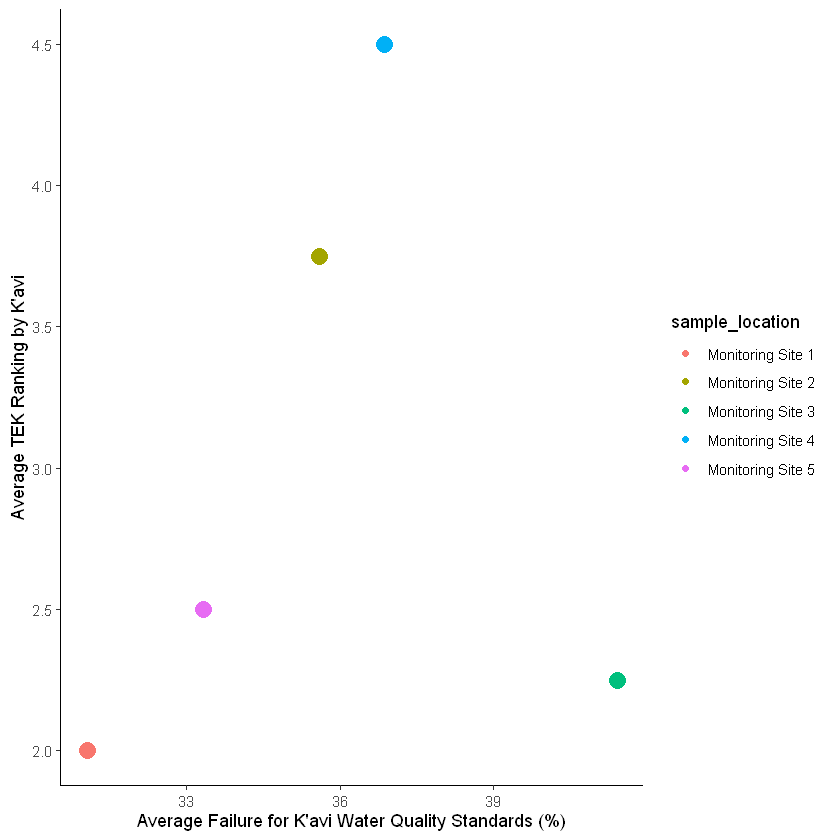

In [8]:

dat %>%
  ggplot(aes(x = average_fail, y = mean_tek)) +
  # plot these data as points, make the point size larger so it's more visible,
  # and color by monitoring site
  geom_point(aes(color = sample_location, size = 2.5)) +
  # add x-axis label
  xlab("Average Failure for K'avi Water Quality Standards (%)") +
  # add y-axis label
  ylab("Average TEK Ranking by K'avi") +
  # remove the legend for the point size
  guides(size = FALSE) +
  # clean up plot by changing the theme
  theme_classic()

## Recap 

What other plots could be made? 

What else would be useful to visualize? 